In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)]

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
!ls /kaggle/input/datasets/kevinjosum/flowers-split/flowers_split
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

test  train


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

2026-04-22 14:37:11.837704: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776868632.030505      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776868632.088178      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776868632.519896      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776868632.519928      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776868632.519931      23 computation_placer.cc:177] computation placer alr

In [3]:
train_dir = '/kaggle/input/datasets/kevinjosum/flowers-split/flowers_split/train'
test_dir = '/kaggle/input/datasets/kevinjosum/flowers-split/flowers_split//test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True
)

Found 10577 images belonging to 13 classes.
(100, 120, 120, 3)


<Figure size 640x480 with 0 Axes>

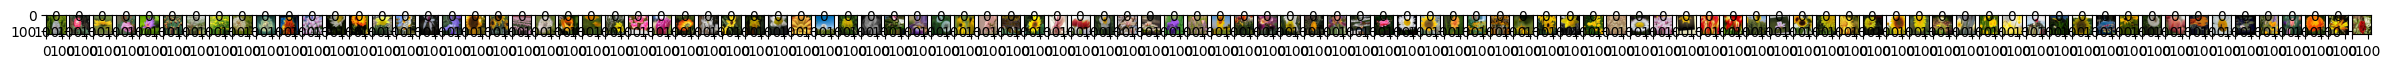

In [4]:
train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (120, 120),
							batch_size = 100,
							class_mode ='categorical',
							)


images , labels = train_generator[0]

print(images.shape)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [5]:
from tensorflow.keras import Model, Input

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(120, 120, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(13, activation='softmax')(x)

modelu = Model(inputs=base_model.input, outputs=output)

modelu.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelu.summary()

I0000 00:00:1776868667.983840      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776868667.989732      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 120, 120, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 120, 120, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 30, 30, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 30, 30, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 15, 15, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,357 (56.65 MB)

 Trainable params: 134,669 (526.05 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

checkpoint = ModelCheckpoint(
    "/kaggle/working/mejor_modelo.keras",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(monitor='loss', patience=5)
checkpoint = ModelCheckpoint(
    "/kaggle/working/mejor_modelo.keras",
    monitor='loss',
    save_best_only=True
)

history = modelu.fit(
    train_generator,
    epochs=70,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/70


I0000 00:00:1776868676.700636      81 service.cc:152] XLA service 0x7bcf1c00e4c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776868676.700676      81 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776868676.700680      81 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776868677.240344      81 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/106 ━━━━━━━━━━━━━━━━━━━━ 27:05 15s/step - accuracy: 0.1000 - loss: 2.8507

I0000 00:00:1776868689.984294      81 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


106/106 ━━━━━━━━━━━━━━━━━━━━ 100s 805ms/step - accuracy: 0.2453 - loss: 2.2958
Epoch 2/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 55s 519ms/step - accuracy: 0.5400 - loss: 1.4656
Epoch 3/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 59s 557ms/step - accuracy: 0.6187 - loss: 1.2211
Epoch 4/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 58s 545ms/step - accuracy: 0.6530 - loss: 1.0965
Epoch 5/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 57s 531ms/step - accuracy: 0.6642 - loss: 1.0344
Epoch 6/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 58s 548ms/step - accuracy: 0.6910 - loss: 0.9714
Epoch 7/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 611ms/step - accuracy: 0.6931 - loss: 0.9533
Epoch 8/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 69s 653ms/step - accuracy: 0.7092 - loss: 0.9022
Epoch 9/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 60s 564ms/step - accuracy: 0.7145 - loss: 0.8854
Epoch 10/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 58s 542ms/step - accuracy: 0.7265 - loss: 0.8476
Epoch 11/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 56s 523ms/step - accuracy: 0.7190 - loss: 0.8581
Epoch 12/70
106/106 ━━━━━━━━━

In [7]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(120, 120),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = modelu.evaluate(test_generator)

print('\nTest accuracy:\n', test_acc)

Found 2646 images belonging to 13 classes.
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 251ms/step - accuracy: 0.7957 - loss: 0.6036

Test accuracy:
 0.8189720511436462


In [8]:
import numpy as np

y_pred = modelu.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       200
           1       0.67      0.55      0.60       196
           2       0.76      0.74      0.75       205
           3       0.75      0.82      0.79       196
           4       0.73      0.80      0.76       210
           5       0.83      0.86      0.84       194
           6       0.92      0.91      0.91       211
           7       0.92      0.89      0.90       211
           8       0.74      0.75      0.75       210
           9       0.84      0.90      0.87       200
          10       0.92      0.89      0.91       206
          11       0.86      0.90      0.88       210
          12       0.84      0.73      0.78       197

    accuracy                           0.82      2646
   macro avg       0.82      0.82      0.82      2646
weighted avg       0.82      0.82      0.82      2646



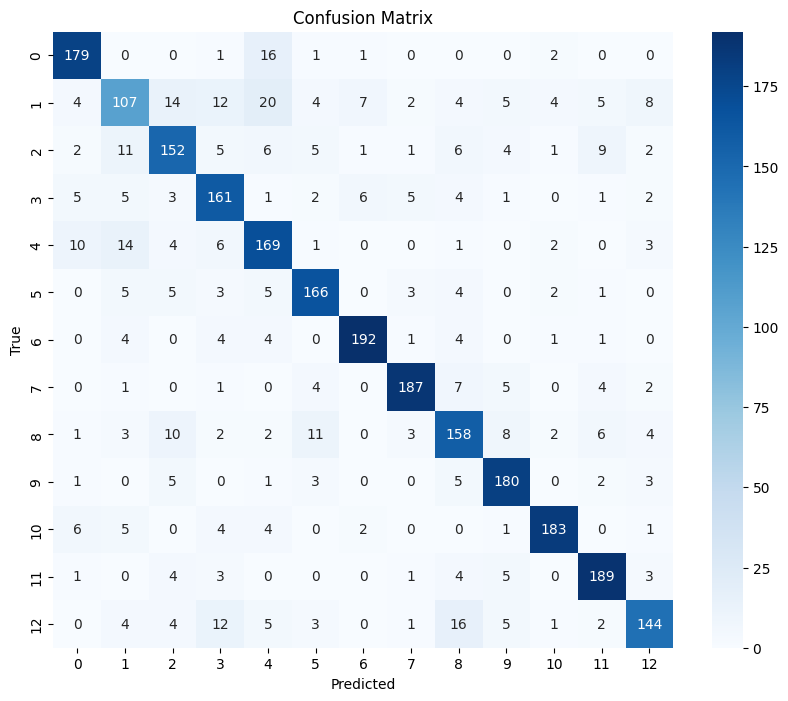

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [11]:
modelu.save("/kaggle/working/mi_modelo2.keras")